<a href="https://colab.research.google.com/github/masaki-kawa/uts-study-notes/blob/main/data/raw/colab/Deep_Learning_Lab5_Exercise2_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Market Prediction using LSTM
### *Netflix Dataset*

----------------------------------------------



# Predicting the closing prices of Netflix stock data

## Dataset

For many analysts and researchers, forecasting stock prices has been a difficult task. By providing supporting information like the future direction of the stock market, good and effective prediction systems for the stock market help traders, investors, and analysts. The dataset we will be using for this exercise is the Netflix Stock Data.

`Link to the dataset: `https://www.kaggle.com/datasets/jainshukal/netflix-stock-price


## Objective

Our goal is to use a LSTM model to predict the closing prices for netflix stock data

## Instructions

This is a guided exercise where some of the code have already been pre-defined. Your task is to fill the remaining part of the code (it will be highlighted with placehoders) to train and evaluate your model.

In this second exercise, we will learn how to apply Long short-term memory (LSTM) on a time series data. Here, we will be using the Netflix stock data for the analysis.

This exercise is split in several parts:
1.   Loading and Exploration of the Dataset
2.   Preparing the Dataset
3.   Defining the Architecture of LSTM
4.   Training and Evaluation of the LSTM Model
5.   Analysing the Results


## Exercise 2

### 1. Loading and Exploration of the Dataset

**[1.1]** First we need to import the relevant Pytorch and Python libraries

In [ ]:
# Solution
# Library for numerical computations and working with arrays.
import numpy as np

# Data manipulation and analysis library, ideal for working with tabular data.
import pandas as pd

# Library for creating visualizations in Python.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Preprocessing module from Scikit-learn, specifically for scaling features to a range.
from sklearn.preprocessing import MinMaxScaler

# Core PyTorch libraries for tensor computations, neural network basics, and common functions.
import torch
from torch import nn

# DataLoader for batching, loading data; TensorDataset for wrapping tensors into datasets.
from torch.utils.data import DataLoader, TensorDataset

# To get the perfomance metrices and ease of calculation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

**[1.2]** Now we will choose the device type [CPU/GPU] in such a way that if GPU is available then use GPU otherwise use CPU.

In [ ]:
# Solution
# Check if GPU is available and set PyTorch to use GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


**[1.3]** Let's Load the data and returns the top 5 rows.

In [ ]:
# Solution
url = "https://drive.google.com/uc?export=download&id=1V5uziuHBu9QHfCCUuCOd_QVN7TMBvQHF"
data = pd.read_csv(url)
data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-12-16,119.800003,123.000000,118.089996,122.639999,122.639999,13181000
1,2015-12-17,123.970001,126.349998,122.419998,122.510002,122.510002,17284900
2,2015-12-18,120.849998,122.190002,117.919998,118.019997,118.019997,17948100
3,2015-12-21,119.510002,119.589996,115.660004,116.629997,116.629997,11670000
4,2015-12-22,117.300003,117.430000,114.860001,116.239998,116.239998,9689000
...,...,...,...,...,...,...,...
1002,2019-12-10,296.119995,298.940002,292.019989,293.119995,293.119995,10476100
1003,2019-12-11,294.489990,299.429993,294.200012,298.929993,298.929993,5589800
1004,2019-12-12,295.670013,299.170013,295.059998,298.440002,298.440002,4766600
1005,2019-12-13,298.500000,301.799988,297.250000,298.500000,298.500000,3879700


**[1.4]** Now plot the Date and Close columns out of seven columns [Date, Open, High, Low, Close, Adj Close, and Volume].


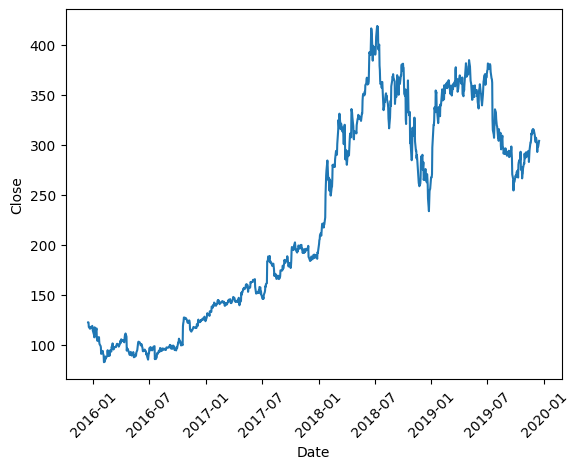

In [ ]:
# Solution
data['Date'] = pd.to_datetime(data['Date'])
plt.xlabel('Date')
plt.ylabel('Close')
plt.xticks(rotation=45)  # Rotate date labels for better readability
plt.plot(data['Date'], data['Close'])

# 2. Preparing the Dataset

**[2.1]** First we will import the `deepcopy` function to create a copy of the DataFrame that doesn't affect the original data. After then we will introduce a function called "prepare_dataframe_for_lstm" that consists of the following attributes:
1. Create a deep copy of the DataFrame
2. Convert the 'Date' column to datetime format
3. Generate new columns for each day in the lookback period, showing the 'Close' price 'n_steps' days ago. This transformation essentially provides historical context needed to predict the future values.

After creating the function


1.   Set the loopback = 7
2.   Call the "prepare_dataframe_for_lstm" by sending the loopback parameter.




In [ ]:
# Solution
# Import the deepcopy function to create a copy of the DataFrame that doesn't affect the original data.
from copy import deepcopy as dc

# Define a function to prepare the DataFrame for LSTM.
def prepare_dataframe_for_lstm(df, n_steps):
    # Create a deep copy of the DataFrame to prevent modifying the original data.
    df = dc(df)

    # Convert the 'Date' column to datetime format and set it as the DataFrame's index.
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    # Generate new columns for each day in the lookback period, showing the 'Close' price 'n_steps' days ago.
    shifted_columns = {f'Close(t-{i})': df['Close'].shift(i) for i in range(1, n_steps + 1)}
    # Add the new columns to the DataFrame.
    df_shifted = df.assign(**shifted_columns)

    # Remove any rows that contain NaN values, which occur at the start of the DataFrame due to shifting.
    df_shifted.dropna(inplace=True)

    # Return the modified DataFrame ready for LSTM training.
    return df_shifted

# How to use the function: Set the lookback period to 7 days/ days of your choice - based on your necessity.
lookback = 7

# Prepare the DataFrame and store it in a new variable.
shifted_df_efficient = prepare_dataframe_for_lstm(data, lookback)

# Display the first few rows of the modified DataFrame.
shifted_df_efficient.head()

,Open,High,Low,Close,Adj Close,Volume,Close(t-1),Close(t-2),Close(t-3),Close(t-4),Close(t-5),Close(t-6),Close(t-7)
Date,,,,,,,,,,,,,
2015-12-28,117.260002,117.349998,113.849998,117.110001,117.110001,8424300,117.330002,118.160004,116.239998,116.629997,118.019997,122.510002,122.639999
2015-12-29,118.190002,119.599998,116.919998,119.120003,119.120003,8159200,117.110001,117.330002,118.160004,116.239998,116.629997,118.019997,122.510002
2015-12-30,118.949997,119.019997,116.430000,116.709999,116.709999,8149700,119.120003,117.110001,117.330002,118.160004,116.239998,116.629997,118.019997
2015-12-31,116.209999,117.459999,114.279999,114.379997,114.379997,9273000,116.709999,119.120003,117.110001,117.330002,118.160004,116.239998,116.629997
2016-01-04,109.000000,110.000000,105.209999,109.959999,109.959999,20794800,114.379997,116.709999,119.120003,117.110001,117.330002,118.160004,116.239998


**[2.2]**
Lets split the size of the full_dataset into train, test and validation data set according to following ratio 70%:15%:15% and save it into train_size, val_size and test_size.

In [ ]:
# Solution
# Calculate the indices for splitting
train_size = int(shifted_df_efficient.shape[0] * 0.7)
validation_size = int(shifted_df_efficient.shape[0] * 0.15)
test_size = shifted_df_efficient.shape[0] - train_size - validation_size
print(train_size)
print(validation_size)
print(test_size)

700
150
150


**[2.3]**
Now split the data based on the size and save it into the dataframe named `train_df`,`validation_df`, and `test_df`.

In [ ]:
# Solution
# Split the data by indices
train_df = shifted_df_efficient.iloc[:train_size, :]
validation_df = shifted_df_efficient.iloc[train_size:train_size+validation_size, :]
test_df = shifted_df_efficient.iloc[train_size+validation_size:, :]

**[2.4]**
Initialize the MinMaxScaler (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) to scale the features to a range between 0 and 1. The following tasks should be introduced:
1. Normalize the training data by fitting the scaler to the training DataFrame and transforming it.
2. Scale the validation and test data according to the feature range.

In [ ]:
# Solution
scaler = MinMaxScaler(feature_range=(0, 1))
train_df[:] = scaler.fit_transform(train_df)
validation_df[:] = scaler.transform(validation_df)
test_df[:] = scaler.transform(test_df)

/tmp/ipykernel_6535/2080034739.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[:] = scaler.fit_transform(train_df)
/tmp/ipykernel_6535/2080034739.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.11987161 0.11520387 0.1150366  0.13481506 0.33768472 0.28256984
 0.55339199 0.563798   0.28965685 0.35750368 0.2380036  0.4103472
 0.38821814 0.31973039 0.60052893 0.90490209 0.51785661 0.4438049
 0.32934407 0.3603825  0.4215209  0.40402084 0.33185841 0.31813516
 0.35725894 0.45514763 0.30799502 0.42809024 0.41235445 0.42744933
 0.37909219 0.35574118 0.30727488 0.25953928 0.29417668 0.28311039
 0.22260939 0.25892654 0.19593761 0.25278154 0.28669351 0.27043126
 0.212

# 3. Create the Sequence

**[3.1]** To prepare the dataset for stock price prediction, we need to frame it as a time series problem. To predict the next day's price, we will use the previous 7 days' price. Let's define a function called `create_sequences` having the following parameters: data, seq_length and target_index value (for this dataset, the target column name is close and the index is 3).

In [ ]:
# Solution
def create_sequences(data, seq_length, target_index = 3):
    """
    Prepares time series data for LSTM by creating overlapping sequences of a specified length,
    excluding the target ('Close' price) from the input sequences.

    Args:
    - data: Normalized data as a numpy array, with rows representing time steps and columns representing features.
    - seq_length: The number of time steps to include in each input sequence, defining the temporal context for predictions.
    - target_index: The index of the target variable ('Close' price) in the data array.

    Returns:
    - xs: An array of input sequences, each sequence providing the LSTM with a window of historical data, excluding the 'Close' price.
    - ys: An array of target values, each corresponding to the outcome ('Close' price) immediately following a sequence.
    """
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        # Extract the sequence of length 'seq_length' starting at index 'i', excluding the 'Close' price.
        x = np.delete(data[i:(i + seq_length), :], target_index, axis=1) # Exclude 'Close' Values from the training data. by default it is 3 as the 4th column in the data is 'Close'
        y = data[i + seq_length, target_index] # Take 'Close' as the label
        xs.append(x) # Append the sequence to the input list.
        ys.append(y) # # Append the target value to the target list.
    return np.array(xs), np.array(ys) # Convert lists to numpy arrays and return them.

**[3.2]** Set the sequence length variable named `seq_length` to 7 and call the `create_sequences` function for train dataframe, validation dataframe and test dataframe.

In [ ]:
# Solution
seq_length = 7  # Example sequence length

# The index of 'Close' column in your dataset
target_index = 3

# Create sequences for each set
# Convert the datasets into Numpy arrays before passing
X_train, y_train = create_sequences(train_df.values, seq_length, target_index)
X_val, y_val = create_sequences(validation_df.values, seq_length, target_index)
X_test, y_test = create_sequences(test_df.values, seq_length, target_index)

**[3.3]** Convert the `X_train`,`y_train`,`X_val`,`y_val`,`X_test` and `y_test` to PyTorch tensors.

In [ ]:
# Solution
# Convert to PyTorch tensors
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float), torch.tensor(y_train, dtype=torch.float))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float), torch.tensor(y_val, dtype=torch.float))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float), torch.tensor(y_test, dtype=torch.float))

# 4. Define the architecture of LSTM

**[4.1]** Let's create a LSTM model named `class LSTM`. This LSTM model processes sequences of data, applying an LSTM layer and a fully connected layer to output predictions. The model focuses on the last timestep's output for its final prediction.

In [ ]:
# Solution
class LSTM(nn.Module):
    """
    A Long Short-Term Memory (LSTM) model for time series prediction.

    Inputs:
    - input_size: The number of features in the input data.
    - hidden_size: The number of features in the hidden state of the LSTM.
    - num_layers: The number of recurrent layers in the LSTM.

    Output:
    - A single value predicted by the model for each sequence in the batch, typically representing a future value in a time series.
    """

    def __init__(self, input_size, hidden_size, num_layers):
        """
        Initializes the LSTM model with the specified architecture parameters.
        """
        super(LSTM, self).__init__()  # Initialize the parent class (nn.Module)
        self.hidden_size = hidden_size  # Number of features in the hidden state
        self.num_layers = num_layers  # Number of LSTM layers

        # The LSTM layer(s) with specified input size, hidden size, and number of layers.
        # 'batch_first=True' indicates that the first dimension of the input represents the batch size.
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Fully connected layer that maps the hidden state output to the predicted value.
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        """
        Defines the forward pass of the model.

        Input:
        - x: Input data with shape (batch_size, sequence_length, input_size).

        Output:
        - out: Model predictions with shape (batch_size, 1).
        """
        # Initialize the hidden state and cell state to zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # Forward pass through LSTM layer(s)
        out, _ = self.lstm(x, (h0, c0))

        # Pass the output of the last time step through the fully connected layer
        out = self.fc(out[:, -1, :])

        return out

**[4.2]** Let's set the model parameters. For number of features, set the input_size=12, hidden_size = 128 and number of stacked LSTM layers, num_layers = 1.

In [ ]:
# Solution
# Model Parameters
input_size = 12  # Number of features
hidden_size = 128  # Number of features in hidden state
num_layers = 1  # Number of stacked LSTM layers

**[4.3]** Let's instantiate the newly created RNN and save it to `model`

In [ ]:
# Solution
model = LSTM(input_size, hidden_size, num_layers).to(device)

**[4.4]** Let's print the model summary

In [ ]:
# Solution
print(model)

LSTM(
  (lstm): LSTM(12, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


### 5. Training and Evaluation of the Model

**[5.1]**  Instantiate a `nn.MSELoss()` and save it into a variable called `loss_function`. After then Instantiate a `torch.optim.Adam()` optimizer with the model's parameters and 0.001 as learning rate and save it into a variable called `optimizer`. Set the num_epochs as 100.

In [ ]:
# Solution
from torch.optim import Adam
# Training Parameters
learning_rate = 0.001
num_epochs = 100
loss_function = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

**[5.2]**  Create variables called `train_losses`, `val_losses`, `train_maes`, `val_maes`, `train_rmses` and `val_rmses`.

In [ ]:
# Solution
train_losses, val_losses = [], []
train_maes, val_maes = [], []
train_rmses, val_rmses = [], []

**[5.3]** Now we will call the DataLoader function that iteratively loads data based on batch size, shuffle and save it into three different variables called `train_loader`, `val_loader` and `test_loader`. Set the `BATCH_SIZE` to 64.

In [ ]:
# Solution
# Create DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

**[5.4]**  Let's define a function called `train_one_epoch` that takes the following parameters model, device, train_loader, optimizer, loss_function. This function is responsible to train our newly created LSTM model.
A nested loop is initiated that extracts data from `train_loader` and introduce the following logics:
- reset the gradients (https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.zero_grad.html)
- perform the forward propagation and get the model predictions
- calculate the loss between the predictions and the actuals
- perform back propagation
- update the weights
- Count the total loss

In [ ]:
# Solution
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

def train_one_epoch(model, device, train_loader, optimizer, loss_function):
    """
    Trains the model for one epoch over the provided training data.

    Args:
    - model: The LSTM model to be trained.
    - device: The device (CPU or GPU) to perform training on.
    - train_loader: DataLoader for the training dataset, providing batches of (input, target) pairs.
    - optimizer: The optimization algorithm used to update model weights.
    - loss_function: The loss function used to compute the discrepancy between model predictions and actual targets.

    Returns:
    - avg_loss: The average loss over all batches in this epoch.
    - mae: The Mean Absolute Error of model predictions against actual targets over all batches.
    - rmse: The Root Mean Squared Error of model predictions against actual targets over all batches.
    """

    model.train()  # Set the model to training mode (enables dropout, batch normalization, etc.)
    running_loss = 0.0  # Accumulator for the loss over all batches
    all_actuals = []  # List to collect all actual target values across batches
    all_predictions = []  # List to collect all model predictions across batches

    # Iterate over batches of data in the train_loader
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        # Move the batch data to the specified device
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(x_batch.to(device)) # Forward propagation to get predicted outcome
        loss = loss_function(outputs, y_batch.unsqueeze(1))
        loss.backward()
        optimizer.step()
        running_loss += loss.item() # Update running loss

        # Collect actual targets and predictions for metric computation
        all_actuals.extend(y_batch.tolist())
        all_predictions.extend(outputs.detach().cpu().numpy().flatten().tolist())

    # Compute average loss for the epoch
    avg_loss = running_loss / len(train_loader)

    # Calculate evaluation metrics for the epoch
    mae = mean_absolute_error(all_actuals, all_predictions)
    rmse = math.sqrt(mean_squared_error(all_actuals, all_predictions))

    return avg_loss, mae, rmse

**[5.5]** To validate the model a nested loop is initiated that extracts data from `val_loader` and introduce the following logics:
- disable computing gradients (https://pytorch.org/docs/stable/generated/torch.no_grad.html)
- perform the forward propagation and get the model predictions
- calculate the loss between the predictions and the actuals
- Count the total loss
- Count the correct outcome

In [ ]:
# Solution
def validate(model, device, loader, loss_function):
    """
    Validates the model's performance on a given dataset.

    Args:
    - model: The LSTM model being evaluated.
    - device: The computational device (CPU or GPU) to use.
    - loader: DataLoader providing batches of validation/test data.
    - loss_function: The loss function used to compute the discrepancy between predictions and targets.

    Returns:
    - avg_loss: The average loss over all batches in the validation/test dataset.
    - mae: Mean Absolute Error of predictions against actual targets over the entire dataset.
    - rmse: Root Mean Squared Error of predictions against actual targets over the entire dataset.
    """
    model.eval()  # Set the model to evaluation mode (disables dropout and batch normalization effects)
    running_loss = 0.0  # Accumulate losses for all batches
    all_actuals = []  # Collect all actual target values across batches
    all_predictions = []  # Collect all model predictions across batches

    with torch.no_grad():  # Disable gradient computation for validation, saving memory and computation
        for x_batch, y_batch in loader:  # Iterate over batches of data
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)  # Move data to the specified device
            outputs = model(x_batch)
            loss = loss_function(outputs, y_batch.unsqueeze(1))  # Compute loss between predictions and actuals
            running_loss += loss.item()  # Accumulate the batch loss

            # Collect all actuals and predictions for computing MAE and RMSE
            all_actuals.extend(y_batch.cpu().numpy().flatten().tolist())
            all_predictions.extend(outputs.cpu().numpy().flatten().tolist())

    # Calculate average loss, MAE, and RMSE for the dataset
    avg_loss = running_loss / len(loader)
    mae = mean_absolute_error(all_actuals, all_predictions)
    rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))

    return avg_loss, mae, rmse

**[5.6]** **Training:** Now it is time to train our model by calling train_one_epoch and validate functions. The evaluation metrics are stored in train_losses, val_losses, train_maes, val_maes, train_rmses, val_rmses by using append function.

In [ ]:
# Solution
# Training loop with validation
for epoch in range(num_epochs):
    # Perform training for one epoch and compute metrics
    train_loss, train_mae, train_rmse = train_one_epoch(model, device, train_loader, optimizer, loss_function)

    # Validate the model's performance on the validation dataset and compute metrics
    val_loss, val_mae, val_rmse = validate(model, device, val_loader, loss_function)

    # Save the metrics for further analysis or monitoring
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_maes.append(train_mae)
    val_maes.append(val_mae)
    train_rmses.append(train_rmse)
    val_rmses.append(val_rmse)

    # Print the computed metrics for the current epoch in a structured format
    print('*' * 50)
    print(f'\nEpoch: {epoch + 1}')
    print(f'Train Loss: {train_loss:.4f}, Train MAE: {train_mae:.4f}, Train RMSE: {train_rmse:.4f}')
    print(f'Val Loss: {val_loss:.4f}, Val MAE: {val_mae:.4f}, Val RMSE: {val_rmse:.4f}')
    print('*' * 50, '\n')

**************************************************

Epoch: 1
Train Loss: 0.1042, Train MAE: 0.2293, Train RMSE: 0.3252
Val Loss: 0.0051, Val MAE: 0.0622, Val RMSE: 0.0759
************************************************** 

**************************************************

Epoch: 2
Train Loss: 0.0152, Train MAE: 0.1106, Train RMSE: 0.1241
Val Loss: 0.0221, Val MAE: 0.1323, Val RMSE: 0.1439
************************************************** 

**************************************************

Epoch: 3
Train Loss: 0.0065, Train MAE: 0.0560, Train RMSE: 0.0809
Val Loss: 0.0025, Val MAE: 0.0391, Val RMSE: 0.0533
************************************************** 

**************************************************

Epoch: 4
Train Loss: 0.0022, Train MAE: 0.0352, Train RMSE: 0.0475
Val Loss: 0.0026, Val MAE: 0.0390, Val RMSE: 0.0542
************************************************** 

**************************************************

Epoch: 5
Train Loss: 0.0013, Train MAE: 0.0247, Trai

**[5.7]** **Testing:** Now it is time to test our model. In this case we could call the validate function (since it is designed in such a way that it could work for test function) by sending the following parameters 1. model, 2. device, 3. test_loader and 4. loss_function.

In [ ]:
# Solution
# Evaluate on test set after all epochs are done
print("Evaluating on test dataset...")
validate(model, device, test_loader, loss_function)

Evaluating on test dataset...


(0.0006459449068643153, 0.020488940752469577, np.float64(0.027538369571538573))

### 6. Analysing the Results

**[6.1]** Let's plot the training and validation losses

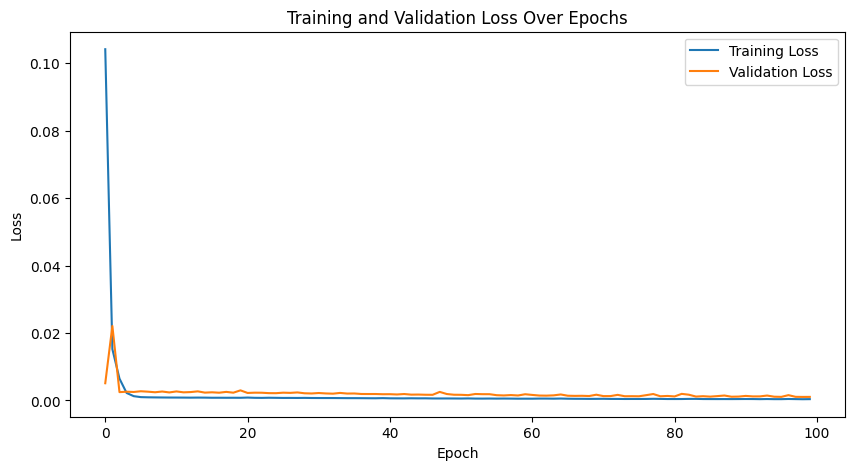

In [ ]:
# Solution
# Plotting the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

**[6.2]** Now plot the training and validation mean absolut error (MAE)

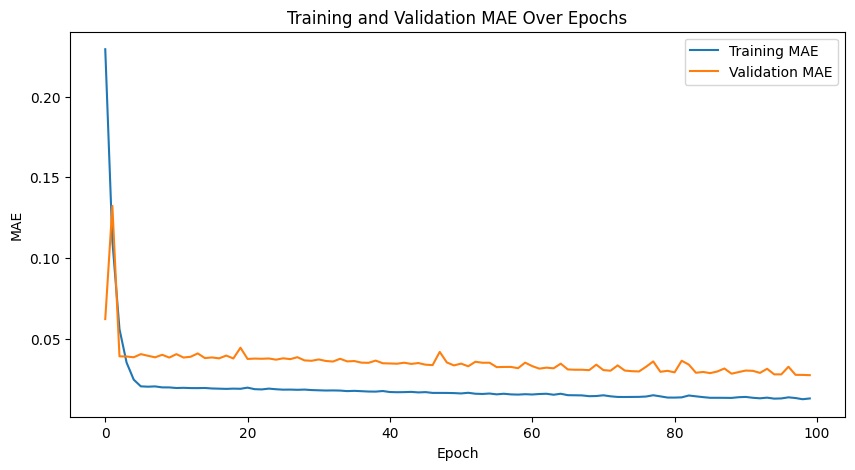

In [ ]:
# Solution
# Plotting the training and validation MAE
plt.figure(figsize=(10, 5))
plt.plot(train_maes, label='Training MAE')
plt.plot(val_maes, label='Validation MAE')
plt.title('Training and Validation MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

**[6.3]** Let's plot the training and validation root mean square error (RMSE)



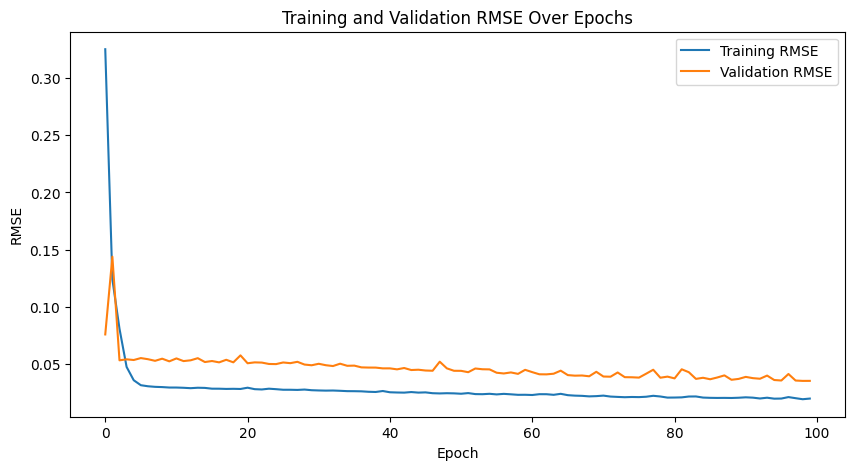

In [ ]:
# Solution
# Plotting the training and validation RMSE
plt.figure(figsize=(10, 5))
plt.plot(train_rmses, label='Training RMSE')
plt.plot(val_rmses, label='Validation RMSE')
plt.title('Training and Validation RMSE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()
plt.show()

**[6.4]** Let's set the model in evaluation mode, prepare the test data as a tensor on the correct device, and generate predictions without gradient tracking.

In [ ]:
# Solution
# Ensure the model is set to evaluation mode to disable dropout and batch normalization layers
model.eval()

# Convert the test data into a PyTorch tensor if it's not already in this format
if not isinstance(X_test, torch.Tensor):
    X_test_tensor = torch.tensor(X_test, dtype=torch.float).to(device)
else:
    X_test_tensor = X_test.to(device)

# Generate predictions for the test data without computing gradients for efficiency
with torch.no_grad():
    predicted_test = model(X_test_tensor).cpu().numpy()

**[6.5]** Let's convert `y_test` to a numpy array for plotting.

In [ ]:
# Solution
# Convert y_test to a numpy array if it's stored as a PyTorch tensor for easy plotting
if isinstance(y_test, torch.Tensor):
    y_test_numpy = y_test.cpu().numpy()
else:
    y_test_numpy = y_test

**[6.6]** Let's displays actual vs. predicted closing price on test dates with matplotlib.

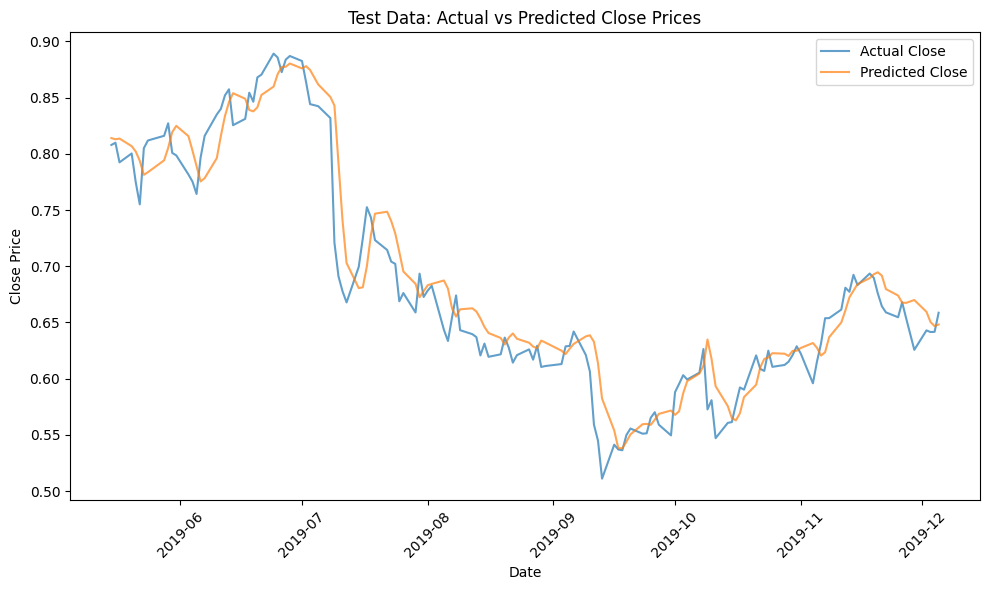

In [ ]:
# Solution
# Extract dates for plotting from the test DataFrame's index
test_dates = test_df.index[:len(predicted_test)]

# Plotting the actual and predicted 'Close' prices on the test dataset
plt.figure(figsize=(10, 6))
plt.plot(test_dates, y_test_numpy, label='Actual Close', alpha=0.7)
plt.plot(test_dates, predicted_test, label='Predicted Close', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Test Data: Actual vs Predicted Close Prices')
plt.legend()
plt.xticks(rotation=45)  # Improve readability by rotating date labels
plt.tight_layout()  # Adjust the layout to accommodate the rotated labels
plt.show()